# ML+ — Pipeline Results & Target-Transform Comparison

**Part 1**: Loads heatmaps directly from the pipeline's `process_eval_results.parquet` — no recomputation.  
Mode labels use the format **`process_model / time_model`**:

| Label | Description |
|---|---|
| `baseline` | `statistical` — fitted distributions only |
| `heuristic / baseline` | Heuristic miner + fitted distributions |
| `heuristic / ml_global` | Heuristic miner + one ML model for all activities |
| `heuristic / ml_local` | Heuristic miner + separate ML model per activity |

**Part 2**: Compares target transforms (log vs direct) by rerunning only the ML modes.

In [16]:
import os, sys, warnings
os.environ['TQDM_DISABLE'] = '1'
warnings.filterwarnings('ignore')
import logging
logging.getLogger('pm4py').setLevel(logging.ERROR)
logging.captureWarnings(True)

SRC_DIR = os.path.dirname(os.path.abspath('__file__'))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
pd.options.mode.chained_assignment = None

from modelling_utils import comprehensive_simulation_evaluation
from sim_extractor import extract_process
from simulation import ProcessSimulation

print('Setup done.')

Setup done.


In [17]:
def _plot_short_heatmap(target_df, title, save_path=None, agg='mean', split='test'):
    """Exact copy of modelling.py version — ActJSDiv · DurWAPE · DurMAE · EdgeF1Err · FitnessErr · PrecisionErr · Overall."""
    if target_df is None or target_df.empty or 'mode' not in target_df.columns:
        return

    _col_js     = f'{split}_activity_metrics_js_divergence'
    _col_wape   = f'{split}_duration_metrics_activity_duration_wape'
    _col_dur_a  = f'{split}_duration_metrics_activity_duration_error'   # fallback (MAPE)
    _col_mae    = f'{split}_duration_metrics_activity_duration_mae'
    _col_f1     = f'{split}_control_flow_metrics_edge_f1_error'
    _col_fit    = f'{split}_conformance_metrics_fitness_error'
    _col_prec   = f'{split}_conformance_metrics_precision_error'
    _col_ov     = f'{split}_overall_error'

    _col_dur = _col_wape if _col_wape in target_df.columns else _col_dur_a

    all_metric_cols = [_col_js, _col_dur, _col_mae, _col_f1, _col_fit, _col_prec, _col_ov]
    needed = [_col_js, _col_f1]
    if not any(c in target_df.columns for c in needed):
        return

    agg_cols = [c for c in all_metric_cols if c in target_df.columns]
    mode_avg = (target_df.groupby('mode')[agg_cols].median()
                if agg == 'median' else target_df.groupby('mode')[agg_cols].mean())

    hm = pd.DataFrame(index=mode_avg.index)
    _mae_actual_by_mode: dict = {}

    if _col_js in mode_avg.columns:
        hm['ActJSDiv']   = mode_avg[_col_js]
    if _col_dur in mode_avg.columns:
        _dur_label = 'DurWAPE' if 'wape' in _col_dur else 'DurMAPE'
        hm[_dur_label]   = mode_avg[_col_dur]
    if _col_mae in mode_avg.columns:
        _mae_raw = mode_avg[_col_mae]
        _mae_min, _mae_max = _mae_raw.min(), _mae_raw.max()
        _mae_rng = _mae_max - _mae_min
        hm['DurMAE'] = (_mae_raw - _mae_min) / _mae_rng if _mae_rng > 0 else 0.0
        _mae_actual_by_mode = _mae_raw.to_dict()
    if _col_f1 in mode_avg.columns:
        hm['EdgeF1Err']   = mode_avg[_col_f1]
    if _col_fit in mode_avg.columns:
        hm['FitnessErr']  = mode_avg[_col_fit]
    if _col_prec in mode_avg.columns:
        hm['PrecisionErr'] = mode_avg[_col_prec]

    err_cols = [c for c in ['ActJSDiv', 'DurWAPE', 'DurMAPE', 'DurMAE',
                             'EdgeF1Err', 'FitnessErr', 'PrecisionErr']
                if c in hm.columns]
    if err_cols:
        hm['Overall'] = hm[err_cols].mean(axis=1)

    def _display_mode(m):
        m = str(m)
        if not m.startswith('petri_net_'):
            return m
        rest = m[len('petri_net_'):]
        if rest.endswith('_ml_plus_global'):
            return rest[:-len('_ml_plus_global')] + ' / ml_global'
        if rest.endswith('_ml_plus_per_act'):
            return rest[:-len('_ml_plus_per_act')] + ' / ml_local'
        return rest + ' / baseline'

    _raw_modes = list(hm.index)
    _mae_by_display = {_display_mode(m): _mae_actual_by_mode.get(m, float('nan'))
                       for m in _raw_modes}
    hm.index = [_display_mode(m) for m in _raw_modes]
    hm = hm.sort_values('Overall', ascending=True)

    # DurMAE column: show actual minutes in annotation; all others 3 dp
    _annot_rows = []
    for _dm in hm.index:
        _row = []
        for _hm_col in hm.columns:
            _val = hm.loc[_dm, _hm_col]
            if _hm_col == 'DurMAE':
                _actual = _mae_by_display.get(_dm, float('nan'))
                _row.append(f'{_actual:.1f}' if not pd.isna(_actual) else '')
            else:
                _row.append(f'{_val:.3f}' if not pd.isna(_val) else '')
        _annot_rows.append(_row)
    _annot_arr = np.array(_annot_rows)

    n_rows = max(2, len(hm))
    fig, ax = plt.subplots(figsize=(max(10, len(hm.columns) * 1.5), n_rows * 0.9 + 1.8))
    sep = len(hm.columns) - 1
    sns.heatmap(hm.round(3), annot=_annot_arr, fmt='', cmap='RdYlGn_r',
                vmin=0, vmax=1, linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Error (0 = best)', 'shrink': 0.7}, ax=ax)
    ax.axvline(x=sep, color='navy', linewidth=2.0)
    ax.set_title(
        f'{title}\n0 = best  |  DurMAE = actual minutes (colour normalised)  |  Overall = mean of first {sep} cols',
        fontsize=11, fontweight='bold')
    ax.set_ylabel('Mode')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n{title.upper()}")
    print("-" * 60)
    with pd.option_context('display.max_columns', None, 'display.width', 200):
        print(hm.round(4).to_string())

print('_plot_short_heatmap loaded (modelling.py version).')

_plot_short_heatmap loaded (modelling.py version).


## ML+ functions — needed for Part 2 (direct-transform recompute)

Copied from `modelling.py` so this notebook doesn't trigger the full pipeline on import.  
`target_transform='direct'` skips the log1p so the model learns in the original minutes scale.

In [18]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import ast as _ast

_MLP_ENG_COLS = [
    'feat_hour', 'feat_dayofweek', 'feat_month',
    'feat_act_pos', 'feat_prev_dur', 'feat_prev_dur2', 'feat_case_elapsed',
]

def _mlp_flatten_object_attributes(df):
    if 'object_attributes' not in df.columns:
        return df
    def _parse(x):
        if isinstance(x, dict): return x
        if isinstance(x, str):
            try: return _ast.literal_eval(x)
            except: return {}
        return {}
    attrs   = df['object_attributes'].apply(_parse)
    attr_df = pd.json_normalize(attrs.tolist()).add_prefix('attr_')
    attr_df.index = df.index
    return pd.concat([df.drop(columns=['object_attributes']), attr_df], axis=1)


def _mlp_add_features(df):
    out = df.sort_values(['case_id', 'timestamp_start']).copy()
    out['feat_hour']         = out['timestamp_start'].dt.hour
    out['feat_dayofweek']    = out['timestamp_start'].dt.dayofweek
    out['feat_month']        = out['timestamp_start'].dt.month
    out['feat_act_pos']      = out.groupby('case_id').cumcount()
    out['feat_prev_dur']     = out.groupby('case_id')['duration'].shift(1).fillna(0.0)
    out['feat_prev_dur2']    = out.groupby('case_id')['duration'].shift(2).fillna(0.0)
    out['feat_case_elapsed'] = (
        out['timestamp_start']
        - out.groupby('case_id')['timestamp_start'].transform('min')
    ).dt.total_seconds() / 60.0
    return out


def _mlp_fit_model_with_oof(sub, feat_cols, n_splits=5, target_transform='log'):
    """Select best sklearn model by CV MAE.
    target_transform: 'log' (log1p — pipeline default), 'direct' (no transform).
    Returns (model, scaler, name), oof_resid.
    """
    if len(sub) < 20 or not feat_cols:
        return None, None

    X = sub[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
    y = sub['duration'].values
    n = len(sub)
    k = min(n_splits, n // 2)
    if k < 2:
        return None, None

    # --- target transform -------------------------------------------------
    if target_transform == 'log':
        y_t = np.log1p(y)
        inv = lambda p: np.clip(np.expm1(p), 0, None)
    else:   # 'direct' — no transform, model works in original scale
        y_t = y.copy()
        inv = lambda p: np.clip(p, 0, None)

    candidates = {
        'ridge': lambda: Ridge(alpha=1.0),
        'huber': lambda: HuberRegressor(epsilon=1.35, max_iter=300),
        'rf':    lambda: RandomForestRegressor(n_estimators=50, max_depth=5,
                                               min_samples_leaf=3, random_state=42),
        'xgb':   lambda: XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                                       subsample=0.8, random_state=42, verbosity=0),
    }
    folds = list(KFold(n_splits=k, shuffle=False).split(X))
    cand_scores, cand_oofs = {}, {}

    for name, make_m in candidates.items():
        oof, scores = np.full(n, np.nan), []
        for tr_idx, val_idx in folds:
            if len(tr_idx) < 2:
                continue
            sc_f, m_f = StandardScaler(), make_m()
            try:
                m_f.fit(sc_f.fit_transform(X[tr_idx]), y_t[tr_idx])
                pred_t = m_f.predict(sc_f.transform(X[val_idx]))
                scores.append(np.mean(np.abs(pred_t - y_t[val_idx])))
                oof[val_idx] = y[val_idx] - inv(pred_t)
            except Exception:
                pass
        if scores:
            cand_scores[name] = np.mean(scores)
            cand_oofs[name]   = oof

    if not cand_scores:
        return None, None

    best_name = min(cand_scores, key=cand_scores.get)
    sc = StandardScaler()
    m  = candidates[best_name]()
    m.fit(sc.fit_transform(X), y_t)

    oof_out = cand_oofs[best_name]
    oof_out = oof_out[~np.isnan(oof_out)]
    return (m, sc, best_name), (oof_out if len(oof_out) >= 5 else None)


def _mlp_train_models(df_train, target_transform='log'):
    """Train ML+ global and per-activity models — same as pipeline."""
    df = df_train.copy()
    df['timestamp_start'] = pd.to_datetime(df['timestamp_start'])
    df['timestamp_end']   = pd.to_datetime(df['timestamp_end'])
    df['duration'] = (df['timestamp_end'] - df['timestamp_start']).dt.total_seconds() / 60.0
    df = df[df['duration'] > 0].copy()

    df = _mlp_flatten_object_attributes(df)
    df = _mlp_add_features(df)

    activity_means = df.groupby('activity')['duration'].median().to_dict()
    global_mean    = float(df['duration'].median())
    df['feat_act_mean_dur'] = df['activity'].map(activity_means).fillna(global_mean)

    attr_cols = [c for c in df.columns if c.startswith('attr_')]
    numeric_attr_cols = [
        c for c in attr_cols
        if pd.to_numeric(df[c], errors='coerce').notna().mean() > 0.5
    ]
    mlp_feat_cols = [
        c for c in (numeric_attr_cols + _MLP_ENG_COLS + ['feat_act_mean_dur'])
        if c in df.columns
    ]

    global_mlp_tuple, _ = _mlp_fit_model_with_oof(df, mlp_feat_cols,
                                                   target_transform=target_transform)
    act_mlp_models = {}
    for act, sub in df.groupby('activity'):
        tpl, _ = _mlp_fit_model_with_oof(sub, mlp_feat_cols,
                                          target_transform=target_transform)
        if tpl is not None:
            act_mlp_models[act] = tpl

    return global_mlp_tuple, act_mlp_models, mlp_feat_cols, activity_means, global_mean


print('ML+ functions loaded.')

ML+ functions loaded.


---
## Part 1: Pipeline results (from parquet)

Loads the latest `process_eval_results.parquet` and shows the same heatmap as the pipeline process results, filtered to heuristic miner modes.

In [19]:
import re

RESULTS = Path(SRC_DIR).parent / 'results'
GOLD    = Path(SRC_DIR).parent / 'data' / 'gold' / 'experiment_1'

def _exp_ts_key(p):
    m = re.search(r'_(\d{8}_\d{6})$', p.name)
    return m.group(1) if m else p.name

exps = sorted(
    (p for p in RESULTS.glob('experiment_*') if (p / 'process_eval_results.parquet').exists()),
    key=_exp_ts_key,
)
EXP = exps[-1]
print(f'Using: {EXP.name}')

# Load pipeline evaluation results
pipeline_df = pd.read_parquet(EXP / 'process_eval_results.parquet')
PROCESSES = sorted(pipeline_df['process'].unique().tolist())

MODE_LABELS = {
    'statistical':                         'baseline',
    'petri_net_heuristic':                 'heuristic / baseline',
    'petri_net_heuristic_ml_plus_global':  'heuristic / ml_global',
    'petri_net_heuristic_ml_plus_per_act': 'heuristic / ml_local',
    'petri_net_alpha':                     'alpha / baseline',
    'petri_net_alpha_ml_plus_global':      'alpha / ml_global',
    'petri_net_alpha_ml_plus_per_act':     'alpha / ml_local',
    'petri_net_inductive':                 'inductive / baseline',
    'petri_net_inductive_ml_plus_global':  'inductive / ml_global',
    'petri_net_inductive_ml_plus_per_act': 'inductive / ml_local',
}

pipeline_df = pipeline_df.copy()
pipeline_df['mode'] = pipeline_df['mode'].map(MODE_LABELS).fillna(pipeline_df['mode'])

HEURISTIC_MODES = ['baseline', 'heuristic / baseline', 'heuristic / ml_global', 'heuristic / ml_local']
heuristic_df = pipeline_df[pipeline_df['mode'].isin(HEURISTIC_MODES)].copy()

print(f'Processes: {PROCESSES}')
print(f'Modes: {heuristic_df["mode"].unique().tolist()}')

# ── Part 2 helpers ─────────────────────────────────────────────────────────────
TRAIN_RATIO   = 0.70
OBJECT_FILTER = {'process_2': 'l01'}

def load_split(process):
    el = pd.read_parquet(GOLD / process / 'datasets' / 'df_event_log.parquet')
    el['timestamp_start'] = pd.to_datetime(el['timestamp_start'])
    el['timestamp_end']   = pd.to_datetime(el['timestamp_end'])
    obj = OBJECT_FILTER.get(process)
    if obj and 'object' in el.columns:
        el = el[el['object'] == obj].copy()
    el = el.dropna(subset=['case_id', 'activity', 'timestamp_start', 'timestamp_end'])
    order  = el.groupby('case_id')['timestamp_start'].min().sort_values().index.tolist()
    n_tr   = max(1, int(len(order) * TRAIN_RATIO))
    tr_ids = set(order[:n_tr])
    te_ids = set(order[n_tr:])
    df_tr  = el[el['case_id'].isin(tr_ids)].copy()
    df_te  = el[el['case_id'].isin(te_ids)].copy()
    agg = {'timestamp_start': ('timestamp_start', 'min'), 'timestamp_end': ('timestamp_end', 'max')}
    if 'object_attributes' in el.columns:
        agg['object_attributes'] = ('object_attributes', 'first')
    pp_te = df_te.groupby('case_id').agg(**agg).reset_index()
    return df_tr, df_te, pp_te

def flatten_eval(mode_label, result):
    """Flatten comprehensive_simulation_evaluation output + derive _error columns."""
    flat = {'mode': mode_label}
    for cat, vals in result.items():
        if isinstance(vals, dict):
            for k, v in vals.items():
                flat[f'test_{cat}_{k}'] = v
        else:
            flat[f'test_{cat}'] = vals
    # Derive error columns that the heatmap function expects
    # (comprehensive_simulation_evaluation returns raw scores, not errors)
    for src, dst in [
        ('test_conformance_metrics_fitness',       'test_conformance_metrics_fitness_error'),
        ('test_conformance_metrics_precision',     'test_conformance_metrics_precision_error'),
    ]:
        if src in flat and dst not in flat:
            v = flat[src]
            flat[dst] = float(1.0 - v) if v == v else float('nan')  # nan-safe
    if ('test_control_flow_metrics_edge_f1_score' in flat
            and 'test_control_flow_metrics_edge_f1_error' not in flat):
        v = flat['test_control_flow_metrics_edge_f1_score']
        flat['test_control_flow_metrics_edge_f1_error'] = float(1.0 - v) if v == v else float('nan')
    return flat

def run_ml_only(process, target_transform='direct'):
    """Run heuristic + ML modes only — used to compare target transforms."""
    print(f'  {process}', end='  ')
    df_tr, df_te, pp_te = load_split(process)
    if df_te['case_id'].nunique() == 0:
        print('→ no test cases'); return []

    stats, _, pm = extract_process(df_tr, mining_algorithm='heuristic',
                                    optimize_mining_hyperparams=False)
    glb_tpl, pa_tpls, feat_cols, act_means, glb_mean = _mlp_train_models(
        df_tr, target_transform=target_transform)

    results = []
    for label, sim_mode in [
        ('heuristic / ml_global', 'petri_net_ml_plus_global'),
        ('heuristic / ml_local',  'petri_net_ml_plus_per_act'),
    ]:
        try:
            sim = ProcessSimulation(stats, pp_te, mode=sim_mode, process_models=pm,
                                    mlp_global_tuple=glb_tpl, mlp_per_act_tuples=pa_tpls,
                                    mlp_feat_cols=feat_cols,
                                    mlp_activity_means=act_means, mlp_global_mean=glb_mean,
                                    verbose=False).run()
            if sim is None or len(sim) == 0:
                continue
            ev = comprehensive_simulation_evaluation(sim, df_te, process_models=pm, verbose=False)
            r  = flatten_eval(label, ev)
            results.append(r)
            print(f'{label}={r.get("test_overall_error", float("nan")):.3f}', end='  ')
        except Exception as e:
            print(f'[{label}] ERR: {e}', end='  ')
    print()
    return results

print('\nSetup done.')

Using: experiment_405_20260629_081127
Processes: ['process_1', 'process_2', 'process_3', 'process_4']
Modes: ['baseline', 'heuristic / baseline', 'heuristic / ml_global', 'heuristic / ml_local']

Setup done.


### Per-process heatmap — pipeline results (same 7-metric format)

### All-processes combined — replica of `process_test_short_median.png`

One row per mode, each cell = **median across all 4 processes**. This is the exact same view as the pipeline's saved `process_test_short_median.png`.

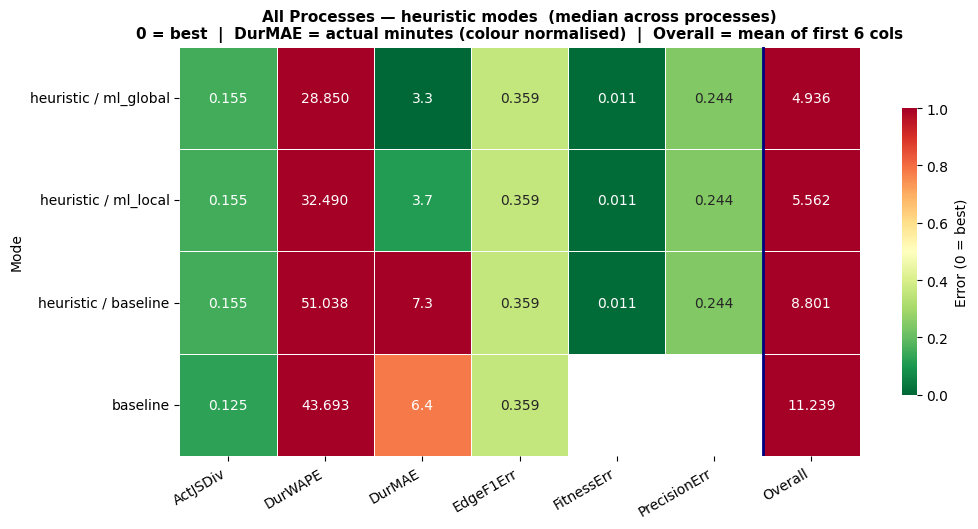


ALL PROCESSES — HEURISTIC MODES  (MEDIAN ACROSS PROCESSES)
------------------------------------------------------------
                       ActJSDiv  DurWAPE  DurMAE  EdgeF1Err  FitnessErr  PrecisionErr  Overall
heuristic / ml_global    0.1547  28.8497  0.0000      0.359      0.0112        0.2436   4.9364
heuristic / ml_local     0.1547  32.4902  0.1127      0.359      0.0112        0.2436   5.5619
heuristic / baseline     0.1547  51.0379  1.0000      0.359      0.0112        0.2436   8.8011
baseline                 0.1249  43.6933  0.7798      0.359         NaN           NaN  11.2392


In [20]:
# Exact replica of process_test_short_median.png — all heuristic modes, median across processes
_plot_short_heatmap(heuristic_df,
                    title='All Processes — heuristic modes  (median across processes)',
                    agg='median', split='test')

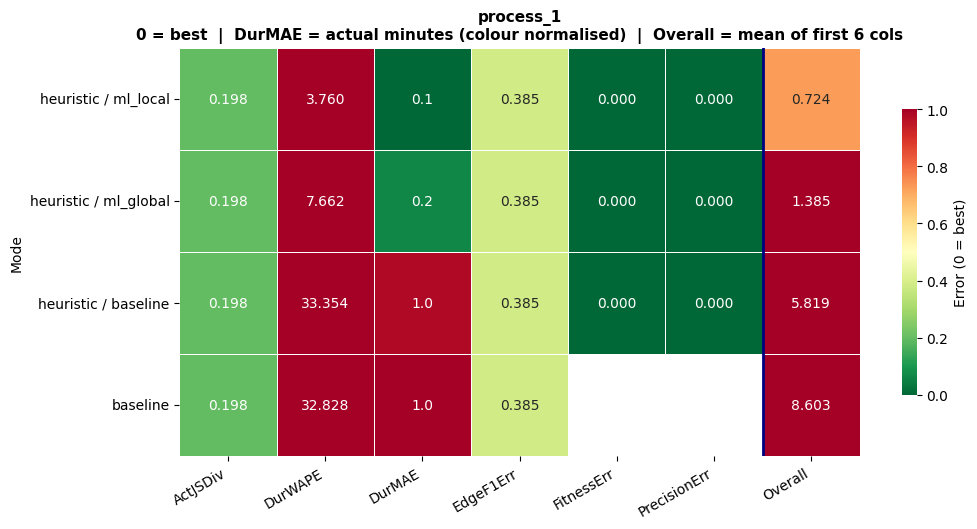


PROCESS_1
------------------------------------------------------------
                       ActJSDiv  DurWAPE  DurMAE  EdgeF1Err  FitnessErr  PrecisionErr  Overall
heuristic / ml_local      0.198   3.7598  0.0000     0.3846         0.0           0.0   0.7237
heuristic / ml_global     0.198   7.6619  0.0647     0.3846         0.0           0.0   1.3849
heuristic / baseline      0.198  33.3538  0.9785     0.3846         0.0           0.0   5.8192
baseline                  0.198  32.8277  1.0000     0.3846         NaN           NaN   8.6026


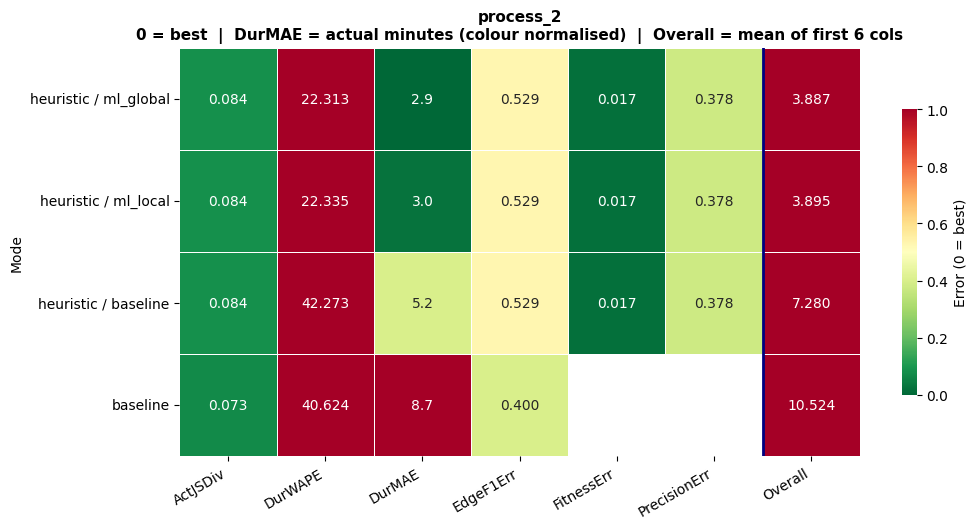


PROCESS_2
------------------------------------------------------------
                       ActJSDiv  DurWAPE  DurMAE  EdgeF1Err  FitnessErr  PrecisionErr  Overall
heuristic / ml_global    0.0842  22.3125  0.0000     0.5294      0.0166        0.3778   3.8868
heuristic / ml_local     0.0842  22.3345  0.0273     0.5294      0.0166        0.3778   3.8950
heuristic / baseline     0.0842  42.2729  0.3999     0.5294      0.0166        0.3778   7.2801
baseline                 0.0733  40.6244  1.0000     0.4000         NaN           NaN  10.5244


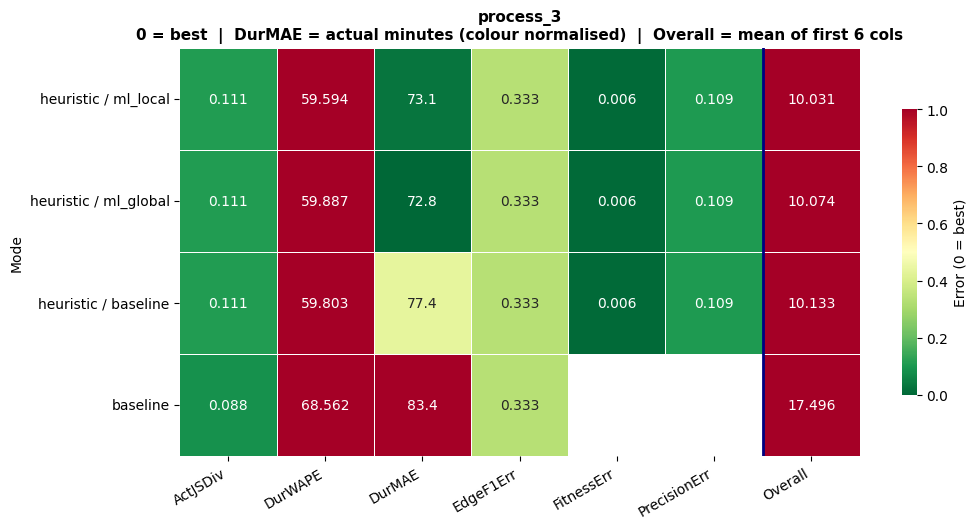


PROCESS_3
------------------------------------------------------------
                       ActJSDiv  DurWAPE  DurMAE  EdgeF1Err  FitnessErr  PrecisionErr  Overall
heuristic / ml_local     0.1113  59.5944  0.0310     0.3333      0.0059        0.1094  10.0309
heuristic / ml_global    0.1113  59.8865  0.0000     0.3333      0.0059        0.1094  10.0744
heuristic / baseline     0.1113  59.8030  0.4364     0.3333      0.0059        0.1094  10.1332
baseline                 0.0877  68.5621  1.0000     0.3333         NaN           NaN  17.4958


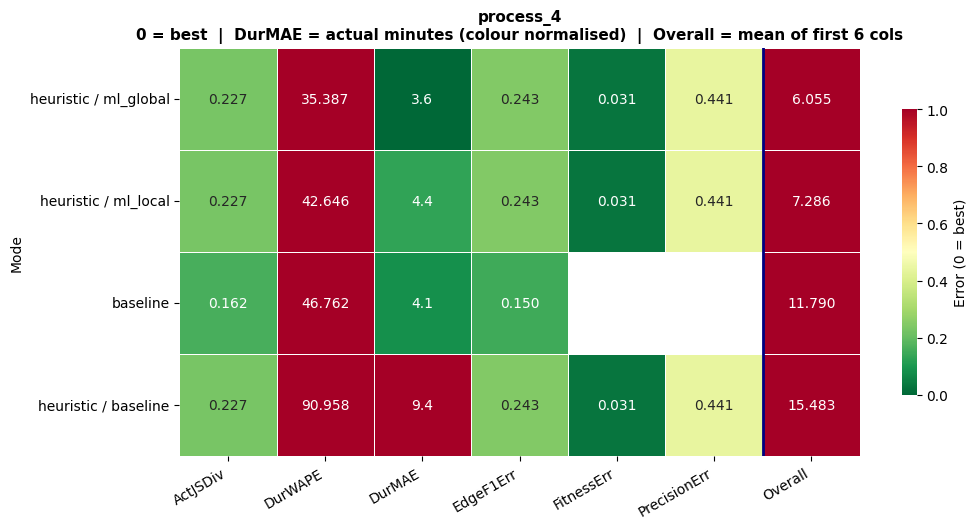


PROCESS_4
------------------------------------------------------------
                       ActJSDiv  DurWAPE  DurMAE  EdgeF1Err  FitnessErr  PrecisionErr  Overall
heuristic / ml_global    0.2273  35.3869  0.0000     0.2432      0.0308        0.4411   6.0549
heuristic / ml_local     0.2273  42.6459  0.1306     0.2432      0.0308        0.4411   7.2865
baseline                 0.1621  46.7621  0.0841     0.1500         NaN           NaN  11.7896
heuristic / baseline     0.2273  90.9578  1.0000     0.2432      0.0308        0.4411  15.4834


In [21]:
for proc in PROCESSES:
    df_proc = heuristic_df[heuristic_df['process'] == proc].copy()
    if df_proc.empty:
        print(f'{proc}: no results in parquet'); continue
    _plot_short_heatmap(df_proc, title=f'{proc}', split='test')

### Cross-process WAPE — all processes × heuristic approaches

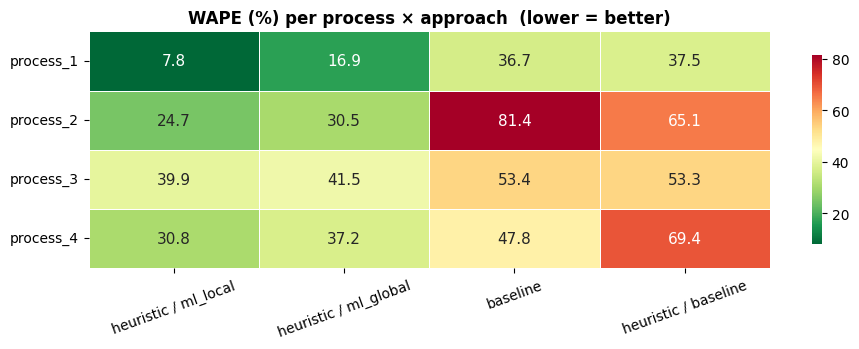

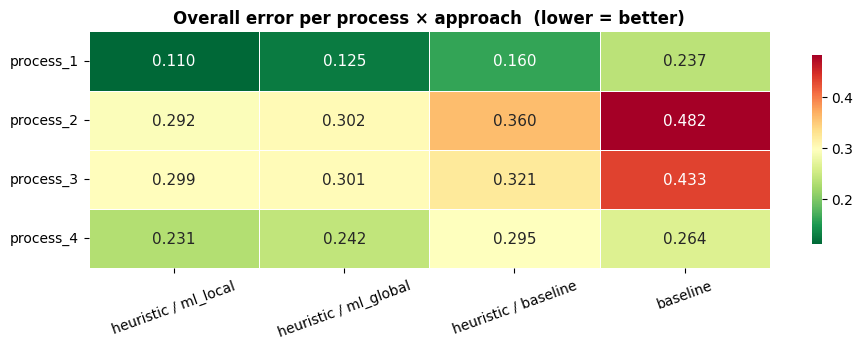

In [22]:
def cross_heatmap(df, row_col, col_col, val_col, title, fmt='.1f', cmap='RdYlGn_r'):
    pivot = df.pivot(index=row_col, columns=col_col, values=val_col).sort_index()
    col_order = pivot.median().sort_values().index.tolist()
    pivot = pivot[col_order]
    fig, ax = plt.subplots(figsize=(max(8, len(col_order) * 2.4), max(3, len(pivot) * 0.9)))
    sns.heatmap(pivot, ax=ax, annot=True, fmt=fmt, cmap=cmap,
                linewidths=0.4, linecolor='white',
                annot_kws={'size': 11}, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=20, labelsize=10)
    ax.tick_params(axis='y', rotation=0,  labelsize=10)
    plt.tight_layout(); plt.show()

wape_rows = heuristic_df[['process', 'mode']].copy()
wape_rows['WAPE_%']  = heuristic_df['test_duration_metrics_activity_duration_error'] * 100
wape_rows['overall'] = heuristic_df['test_overall_error']

cross_heatmap(wape_rows, 'process', 'mode', 'WAPE_%',
              'WAPE (%) per process × approach  (lower = better)')
cross_heatmap(wape_rows, 'process', 'mode', 'overall',
              'Overall error per process × approach  (lower = better)', fmt='.3f')

---
## Improvement strategies: change the target transform

The pipeline always uses `log1p(duration)` when training ML+ models. Here we compare:

| Strategy | Target | Why try it |
|---|---|---|
| `log` (current) | `log1p(y)` | Compresses right tail; stable default |
| `direct` | `y` | No transform — model learns in original minutes scale |

All other settings (features, model candidates, CV folds) are identical.

In [23]:
# Run direct transform — log results already in pipeline parquet
print('Running direct transform (log results come from the pipeline parquet):')
direct_results = {}   # {process: [flat_dicts]}
for proc in PROCESSES:
    direct_results[proc] = run_ml_only(proc, target_transform='direct')

print('\nDone.')

Running direct transform (log results come from the pipeline parquet):
  process_1  
Processing: sterilization_process (8 objects, one whole-process net)
  Mining algorithm: heuristic
  Found 22 unique activities: ['water_supply_prepare' 'water_supply_working' 'destillation_heat'
 'bottling_prepare' 'bottling_working' 'bottling_cool'
 'autoclaving_1_prepare' 'autoclaving_1_heat' 'autoclaving_1_hold'
 'autoclaving_1_cool' 'packaging_prepare' 'packaging_working'
 'warehousing_prepare' 'warehousing_working' 'autoclaving_2_prepare'
 'autoclaving_2_heat' 'autoclaving_2_hold' 'autoclaving_2_cool'
 'autoclaving_3_prepare' 'autoclaving_3_heat' 'autoclaving_3_hold'
 'autoclaving_3_cool']
    water_supply_prepare: best fit = weibull_min (3.2580397428477172, 0.0, 0.11167301834301314)
    water_supply_working: best fit = weibull_min (3.25614757967511, 0.0, 1.3404131363271519)
    destillation_heat: best fit = weibull_min (3.2549303143058177, 0.0, 0.6704339890562847)
    bottling_prepare: best fit 

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9800, fitness=1.0000, precision=1.0000, generalization=0.964261205983456, simplicity=0.9555555555555555
    Selected params: noise=0.2, heur={} (score=0.9800)
    Petri net: 21 places, 22 transitions, 44 arcs


...

replaying log with TBR, completed traces ::   0%|          | 0/800 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/36 [00:00<?, ?it/s]

      quality: score=0.6974, fitness=0.9711, precision=0.6507, generalization=0.5721817244131235, simplicity=0.5957446808510639
    Selected params: noise=0.2, heur={} (score=0.6974)
    Petri net: 20 places, 36 transitions, 75 arcs


replaying log with TBR, completed traces ::   0%|          | 0/36 [00:00<?, ?it/s]

    Stochastic map: 36 transition weights
    Decision-point weights: 1 decision points, 1 with __END__ probability
    Max case length in training: 159
      Step-032 = Umlauf: Start=True, End=True, Transitions={'Step-030 = Produktion': 0.8907216494845361, 'Step-033 = Produkttausch': 0.01443298969072165, 'Step-035 = Ausschub Anlage': 0.05567010309278351, '__END__': 0.03917525773195876}
      Step-030 = Produktion: Start=True, End=True, Transitions={'Step-032 = Umlauf': 0.9751131221719457, 'Step-035 = Ausschub Anlage': 0.011312217194570135, '__END__': 0.013574660633484163}
      Step-035 = Ausschub Anlage: Start=True, End=True, Transitions={'Step-020 = Sterilwasserumlauf (über VLG)': 0.8421052631578947, '__END__': 0.15789473684210525}
      Step-020 = Sterilwasserumlauf (über VLG): Start=True, End=False, Transitions={'Step-021 = Sterilwasserumlauf, Produkt vorziehen': 0.8, 'Step-024 = Sterilwasserumlauf, VLG Produktionsbereit': 0.17142857142857143, 'Step-046 = Anlage Abfahren': 0.02857

Pipeline rows for ML modes: 8  (modes in heuristic_df: ['baseline', 'heuristic / baseline', 'heuristic / ml_global', 'heuristic / ml_local'])
strat_df: (8, 5)  transforms: ['log (pipeline)']


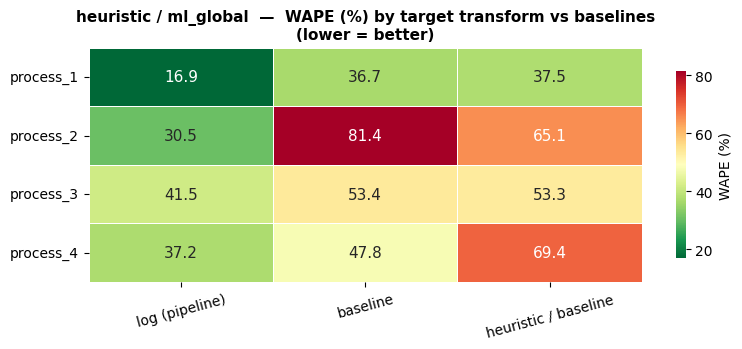

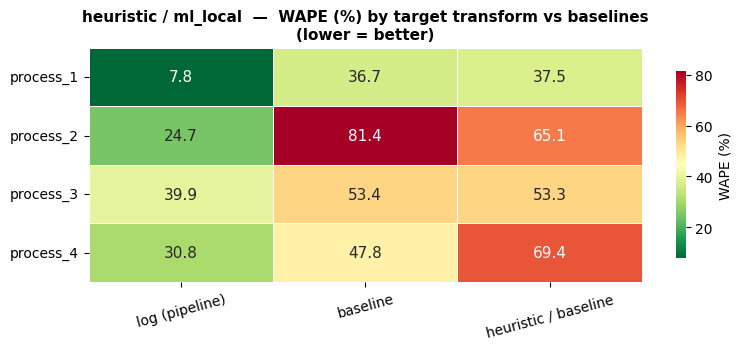


Delta WAPE: direct minus log (negative = direct is better):


In [24]:
ML_MODES = ['heuristic / ml_global', 'heuristic / ml_local']

# Build comparison table: log (from pipeline parquet) vs direct (recomputed)
strat_rows = []

# Log transform — from pipeline parquet
log_sub = heuristic_df[heuristic_df['mode'].isin(ML_MODES)]
print(f'Pipeline rows for ML modes: {len(log_sub)}  (modes in heuristic_df: {heuristic_df["mode"].unique().tolist()})')

for _, row in log_sub.iterrows():
    strat_rows.append({
        'transform': 'log (pipeline)',
        'process':   row['process'],
        'mode':      row['mode'],
        'WAPE_%':    row['test_duration_metrics_activity_duration_error'] * 100,
        'overall':   row['test_overall_error'],
    })

# Direct transform — recomputed
for proc, rows in direct_results.items():
    for r in rows:
        if r['mode'] in ML_MODES:
            strat_rows.append({
                'transform': 'direct',
                'process':   proc,
                'mode':      r['mode'],
                'WAPE_%':    r.get('test_duration_metrics_activity_duration_error', np.nan) * 100,
                'overall':   r.get('test_overall_error', np.nan),
            })

if not strat_rows:
    raise RuntimeError('No strategy rows — re-run the setup cell (a8146788) to reload heuristic_df with updated mode labels.')

strat_df = pd.DataFrame(strat_rows)
print(f'strat_df: {strat_df.shape}  transforms: {strat_df["transform"].unique().tolist()}')

# Baseline WAPE from pipeline parquet for reference
bl_wape = (heuristic_df[heuristic_df['mode'].isin(['baseline', 'heuristic / baseline'])]
           .set_index(['process', 'mode'])['test_duration_metrics_activity_duration_error'] * 100)

# One heatmap per ML mode: rows = process, columns = [log (pipeline), direct, baselines]
for ml_mode in ML_MODES:
    sub = strat_df[strat_df['mode'] == ml_mode]
    if sub.empty: continue

    pivot = sub.pivot(index='process', columns='transform', values='WAPE_%').sort_index()
    col_order = [c for c in ['log (pipeline)', 'direct'] if c in pivot.columns]
    pivot = pivot[col_order]

    # Add baseline columns for reference
    for bl_mode, bl_label in [('baseline', 'baseline'), ('heuristic / baseline', 'heuristic / baseline')]:
        vals = {proc: bl_wape.get((proc, bl_mode), np.nan) for proc in pivot.index}
        pivot[bl_label] = pd.Series(vals)

    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 2.4), max(3, len(pivot) * 0.9)))
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn_r',
                linewidths=0.4, linecolor='white',
                annot_kws={'size': 11}, cbar_kws={'label': 'WAPE (%)', 'shrink': 0.8})
    ax.set_title(f'{ml_mode}  —  WAPE (%) by target transform vs baselines\n(lower = better)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=15, labelsize=10)
    ax.tick_params(axis='y', rotation=0,  labelsize=10)
    plt.tight_layout(); plt.show()

# Delta: direct - log
print('\nDelta WAPE: direct minus log (negative = direct is better):')
for ml_mode in ML_MODES:
    sub = strat_df[strat_df['mode'] == ml_mode]
    if sub.empty: continue
    p = sub.pivot(index='process', columns='transform', values='WAPE_%')
    if 'log (pipeline)' not in p.columns or 'direct' not in p.columns: continue
    delta = (p['direct'] - p['log (pipeline)']).to_frame('direct − log')
    print(f'\n  {ml_mode}:')
    display(delta.round(2).style.format('{:+.2f}%').background_gradient(cmap='RdYlGn', axis=None))

---
## Final consolidated heatmap — per process, all approaches

Same format as the pipeline's process-results heatmap.  
Rows = every approach (baselines + ML variants per transform). **Sorted by Overall error** so the best approach floats to the top.

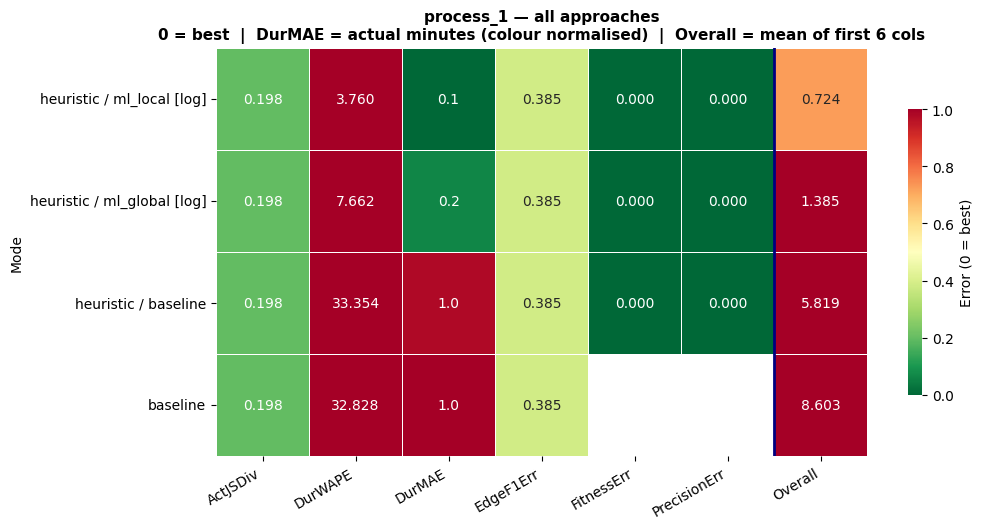


PROCESS_1 — ALL APPROACHES
------------------------------------------------------------
                             ActJSDiv  DurWAPE  DurMAE  EdgeF1Err  FitnessErr  PrecisionErr  Overall
heuristic / ml_local [log]      0.198   3.7598  0.0000     0.3846         0.0           0.0   0.7237
heuristic / ml_global [log]     0.198   7.6619  0.0647     0.3846         0.0           0.0   1.3849
heuristic / baseline            0.198  33.3538  0.9785     0.3846         0.0           0.0   5.8192
baseline                        0.198  32.8277  1.0000     0.3846         NaN           NaN   8.6026


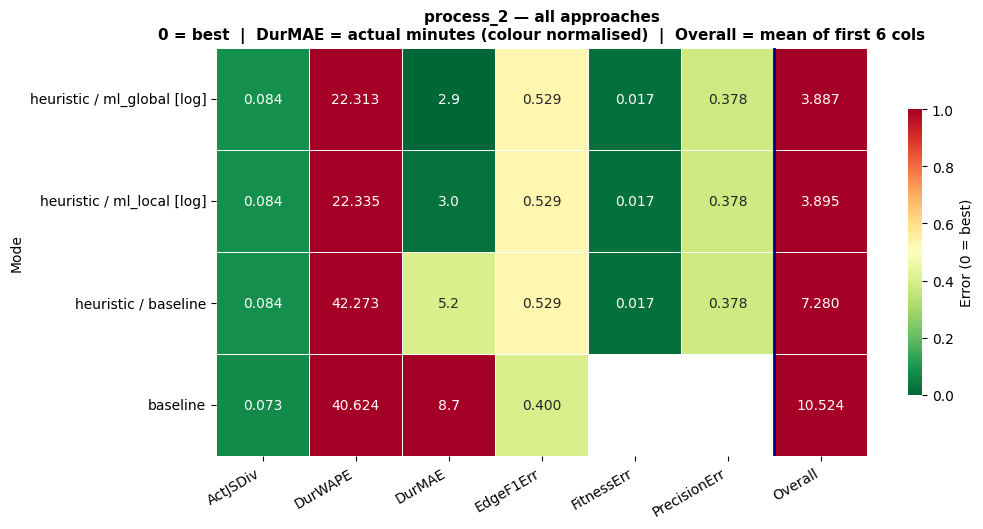


PROCESS_2 — ALL APPROACHES
------------------------------------------------------------
                             ActJSDiv  DurWAPE  DurMAE  EdgeF1Err  FitnessErr  PrecisionErr  Overall
heuristic / ml_global [log]    0.0842  22.3125  0.0000     0.5294      0.0166        0.3778   3.8868
heuristic / ml_local [log]     0.0842  22.3345  0.0273     0.5294      0.0166        0.3778   3.8950
heuristic / baseline           0.0842  42.2729  0.3999     0.5294      0.0166        0.3778   7.2801
baseline                       0.0733  40.6244  1.0000     0.4000         NaN           NaN  10.5244


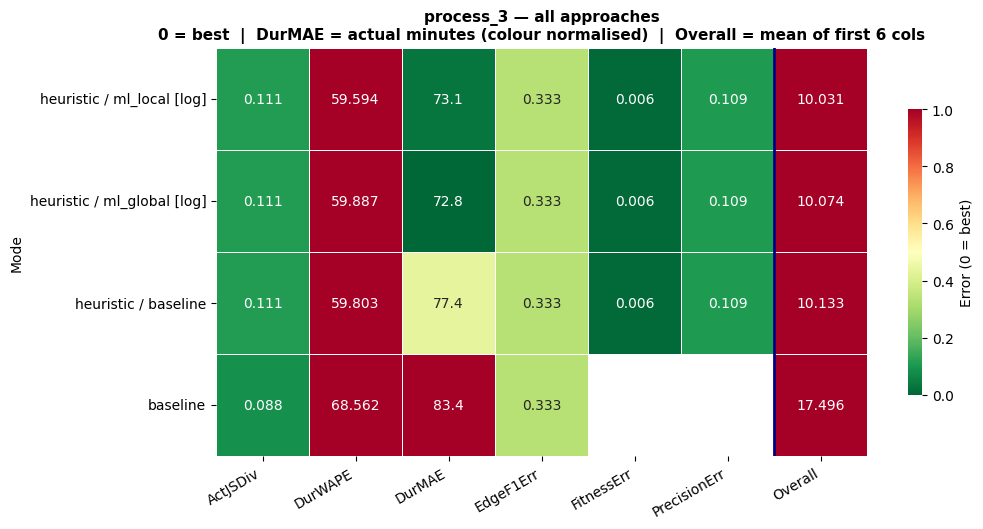


PROCESS_3 — ALL APPROACHES
------------------------------------------------------------
                             ActJSDiv  DurWAPE  DurMAE  EdgeF1Err  FitnessErr  PrecisionErr  Overall
heuristic / ml_local [log]     0.1113  59.5944  0.0310     0.3333      0.0059        0.1094  10.0309
heuristic / ml_global [log]    0.1113  59.8865  0.0000     0.3333      0.0059        0.1094  10.0744
heuristic / baseline           0.1113  59.8030  0.4364     0.3333      0.0059        0.1094  10.1332
baseline                       0.0877  68.5621  1.0000     0.3333         NaN           NaN  17.4958


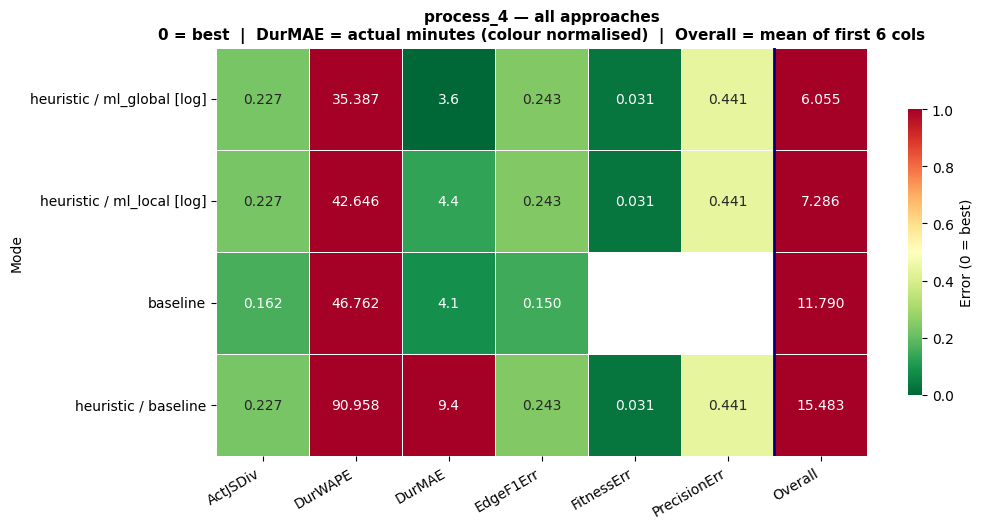


PROCESS_4 — ALL APPROACHES
------------------------------------------------------------
                             ActJSDiv  DurWAPE  DurMAE  EdgeF1Err  FitnessErr  PrecisionErr  Overall
heuristic / ml_global [log]    0.2273  35.3869  0.0000     0.2432      0.0308        0.4411   6.0549
heuristic / ml_local [log]     0.2273  42.6459  0.1306     0.2432      0.0308        0.4411   7.2865
baseline                       0.1621  46.7621  0.0841     0.1500         NaN           NaN  11.7896
heuristic / baseline           0.2273  90.9578  1.0000     0.2432      0.0308        0.4411  15.4834


In [25]:
for proc in PROCESSES:
    # Baselines + log-transform ML from pipeline parquet
    proc_pipe = heuristic_df[heuristic_df['process'] == proc].copy()
    # Rename log-transform ML rows to make the transform explicit
    proc_pipe['mode'] = proc_pipe['mode'].apply(
        lambda m: f'{m} [log]' if m in ML_MODES else m
    )

    # Direct-transform ML — recomputed
    direct_rows = []
    for r in direct_results.get(proc, []):
        if r['mode'] in ML_MODES:
            direct_rows.append({**r, 'mode': f"{r['mode']} [direct]"})

    if direct_rows:
        df_direct = pd.DataFrame(direct_rows)
        df_final = pd.concat([proc_pipe, df_direct], ignore_index=True)
    else:
        df_final = proc_pipe.copy()

    if df_final.empty:
        print(f'{proc}: no results'); continue

    _plot_short_heatmap(df_final, title=f'{proc} — all approaches', split='test')